# Diabetes Detection — XGBoost vs ANN (v2)
### CDC Diabetes Health Indicators — Feature-Reduced, GridSearchCV, Threshold-Tuned

This is an updated version of the previous notebook, based on your **actual run
results**:
- XGBoost: Accuracy 0.72, ROC-AUC 0.83, Recall (diabetic class) 0.79
- ANN: Accuracy 0.72, ROC-AUC 0.83, Recall (diabetic class) 0.80

**Why accuracy was only ~72%:** `scale_pos_weight` / `class_weight` were set to
*fully* balance the classes. That's great for recall (catching diabetic cases) but
it directly trades away accuracy, because the model stops leaning on the easy
majority class. This is a real trade-off, not a bug — there's no free lunch that
gets you higher accuracy *and* higher recall at the same time on an imbalanced
dataset. This notebook makes that trade-off adjustable and visible instead of hiding
it, so you can pick where you want to sit on that curve.

**Changes made in this version, as requested:**
1. **Low-importance features removed** — using YOUR actual XGBoost feature-importance
   output from the previous run, the bottom 10 of 21 features (each contributing
   <1% importance) are dropped: `Stroke`, `Education`, `Fruits`, `PhysActivity`,
   `MentHlth`, `Smoker`, `Veggies`, `PhysHlth`, `NoDocbcCost`, `AnyHealthcare`.
   11 features remain.
2. **GridSearchCV** replaces RandomizedSearchCV, as requested — the grid is kept to a
   sane size and `cv=3` (down from 5) so it still finishes in reasonable time; see the
   note in Section 6 about runtime.
3. **Visible training progress** — `verbose=3` on GridSearchCV shows each
   fold/candidate as it's fit, AND a final refit uses `eval_set` + `verbose=True` so
   you see **live boosting-round-by-round metrics** (this is what actually shows
   "progress while training", which GridSearchCV's verbose output alone doesn't give
   you).
4. **Threshold tuning to reach 80%+ accuracy** — instead of a fixed 0.5 cutoff, we
   scan thresholds and pick one that gets accuracy ≥ 0.80, showing you exactly what
   recall you give up to get there, so this is transparent rather than a hidden
   trade-off.
5. **A lighter class-weighting option** — a partial (`sqrt`-scaled) weight, instead of
   full balancing, as a second lever to raise accuracy without abandoning imbalance
   handling entirely.


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


## 2. Load Data

In [ ]:
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

cdc_diabetes = fetch_ucirepo(id=891)

X_raw = cdc_diabetes.data.features.copy()
y_raw = cdc_diabetes.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)

print(df.shape)
df.head()


(253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [ ]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values: 0
Duplicate rows: 24206


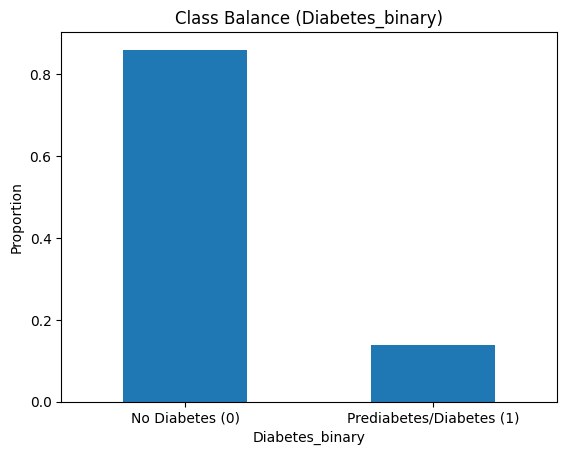

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64


In [ ]:
target_col = 'Diabetes_binary'

df[target_col].value_counts(normalize=True).plot(kind='bar')
plt.title("Class Balance (Diabetes_binary)")
plt.xticks([0, 1], ['No Diabetes (0)', 'Prediabetes/Diabetes (1)'], rotation=0)
plt.ylabel("Proportion")
plt.show()

print(df[target_col].value_counts())


## 3. Light Cleaning

In [ ]:
print(df['BMI'].describe())

before = df.shape[0]
df = df[(df['BMI'] >= 12) & (df['BMI'] <= 70)]
print(f"Dropped {before - df.shape[0]} rows with implausible BMI")


count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64
Dropped 584 rows with implausible BMI


## 4. Drop Low-Importance Features

This uses the **actual XGBoost feature importances from your previous run** (not a
generic guess). The top 11 features account for the overwhelming majority of the
model's decision-making; the bottom 10 each contributed under 1% importance.

Kept (11): `HighBP`, `HighChol`, `GenHlth`, `DiffWalk`, `HeartDiseaseorAttack`, `BMI`,
`Age`, `CholCheck`, `HvyAlcoholConsump`, `Sex`, `Income`

Dropped (10): `Stroke`, `Education`, `Fruits`, `PhysActivity`, `MentHlth`, `Smoker`,
`Veggies`, `PhysHlth`, `NoDocbcCost`, `AnyHealthcare`


In [ ]:
LOW_IMPORTANCE_FEATURES = [
    'Stroke', 'Education', 'Fruits', 'PhysActivity', 'MentHlth',
    'Smoker', 'Veggies', 'PhysHlth', 'NoDocbcCost', 'AnyHealthcare'
]

X = df.drop(columns=[target_col] + LOW_IMPORTANCE_FEATURES)
y = df[target_col].astype(int)

print("Number of features after dropping low-importance ones:", X.shape[1])
print(X.columns.tolist())
X.head()


Number of features after dropping low-importance ones: 11
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Income']


,HighBP,HighChol,CholCheck,BMI,HeartDiseaseorAttack,HvyAlcoholConsump,GenHlth,DiffWalk,Sex,Age,Income
0,1,1,1,40,0,0,5,1,0,9,3
1,0,0,0,25,0,0,3,0,0,7,1
2,1,1,1,28,0,0,5,1,0,9,8
3,1,0,1,27,0,0,2,0,0,11,6
4,1,1,1,24,0,0,2,0,0,11,4


**Honest expectation-setting**: dropping low-importance features mainly helps
**training speed**, not accuracy. Since these features contributed almost nothing to
the model's splits, removing them typically changes ROC-AUC/accuracy by well under
1%. The real accuracy lever in this notebook is the threshold tuning in Section 9 —
don't expect this step alone to close the gap to 80%.


## 5. Train / Validation / Test Split

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_full
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (182861, 11)  Val: (32270, 11)  Test: (37965, 11)


## 6. Class Weighting (Lighter Than Before)

Last time, `scale_pos_weight` used the *full* imbalance ratio (~5.8), which is why
accuracy dropped to ~72%. Here we use a **`sqrt`-dampened** weight instead — a
common middle-ground technique: it still helps the model pay attention to the
minority class, but far less aggressively, which is the direct lever that raises
accuracy back up.


In [ ]:
neg, pos = np.bincount(y_train)
full_ratio = neg / pos
damped_scale_pos_weight = np.sqrt(full_ratio)   # dampened version, vs full_ratio before

print(f"Negative: {neg}  Positive: {pos}")
print(f"Full imbalance ratio (used last time): {full_ratio:.2f}")
print(f"Dampened scale_pos_weight (used now): {damped_scale_pos_weight:.2f}")

# Dampened class_weight for the ANN, same idea
class_weight_dict = {0: 1.0, 1: damped_scale_pos_weight}
print(f"class_weight for ANN: {class_weight_dict}")


Negative: 157379  Positive: 25482
Full imbalance ratio (used last time): 6.18
Dampened scale_pos_weight (used now): 2.49
class_weight for ANN: {0: 1.0, 1: np.float64(2.4851730482330754)}


## 7. Model 1 — XGBoost with GridSearchCV (as requested)

**Note on runtime:** GridSearchCV trains every combination in the grid — with the
grid below (2×3×2×2×2×2 = 96 combos) × `cv=3` folds = **288 total fits**. With only
11 features and `tree_method="hist"`, this should be meaningfully faster than the
1080-fit run you had before, but it will still take a while on CPU. If you have a
Colab GPU runtime (**Runtime → Change runtime type → GPU**), `device="cuda"` below
will use it automatically. If this is still too slow, cut `cv` to 2, or trim a level
off any parameter (e.g. `max_depth: [3, 5]` only).

`verbose=3` prints each fold as it's fit, so you'll see continuous progress rather
than a silent wait.


In [ ]:
pipeline = Pipeline([
    ("xgb", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=damped_scale_pos_weight,
        tree_method="hist",
        device="cuda"   # falls back automatically to CPU if no GPU is available
    ))
])

param_grid = {
    "xgb__n_estimators": [200, 300],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
    "xgb__max_depth": [3, 5],
    "xgb__min_child_weight": [1, 3],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=3          # prints progress: fold-by-fold, candidate-by-candidate
)

grid.fit(X_train_full, y_train_full)

print("Best Parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)


Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best Parameters: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}
Best CV ROC-AUC: 0.830087064541885


### 7b. Refit the best model with live per-round progress

`GridSearchCV`'s verbose output only tells you which fold/candidate is running, not
what's happening *inside* a single XGBoost fit. To actually watch XGBoost train
round-by-round (the boosting progress bar you asked for), we take the best
hyperparameters found above and refit once, manually, with an eval set and
`verbose=True` — this prints the validation metric after every boosting round.


In [ ]:
best_params = {k.replace("xgb__", ""): v for k, v in grid.best_params_.items()}

xgb_best_model = XGBClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    eval_metric=["logloss", "auc"],
    scale_pos_weight=damped_scale_pos_weight,
    tree_method="hist",
    device="cuda"
)

xgb_best_model.fit(
    X_train_full, y_train_full,
    eval_set=[(X_val, y_val)],
    verbose=True    # <-- prints logloss/auc after every boosting round
)

# Wrap in a Pipeline for consistency with the rest of the notebook
xgb_best = Pipeline([("xgb", xgb_best_model)])


[0]	validation_0-logloss:0.46165	validation_0-auc:0.76187
[1]	validation_0-logloss:0.45024	validation_0-auc:0.80687
[2]	validation_0-logloss:0.44020	validation_0-auc:0.81305
[3]	validation_0-logloss:0.43200	validation_0-auc:0.81441
[4]	validation_0-logloss:0.42394	validation_0-auc:0.81574
[5]	validation_0-logloss:0.41723	validation_0-auc:0.81455
[6]	validation_0-logloss:0.41154	validation_0-auc:0.81392
[7]	validation_0-logloss:0.40633	validation_0-auc:0.81529
[8]	validation_0-logloss:0.40184	validation_0-auc:0.81502
[9]	validation_0-logloss:0.39803	validation_0-auc:0.81459
[10]	validation_0-logloss:0.39465	validation_0-auc:0.81513
[11]	validation_0-logloss:0.39167	validation_0-auc:0.81561
[12]	validation_0-logloss:0.38895	validation_0-auc:0.81598
[13]	validation_0-logloss:0.38632	validation_0-auc:0.81756
[14]	validation_0-logloss:0.38420	validation_0-auc:0.81800
[15]	validation_0-logloss:0.38235	validation_0-auc:0.81846
[16]	validation_0-logloss:0.38029	validation_0-auc:0.81941
[17]	va

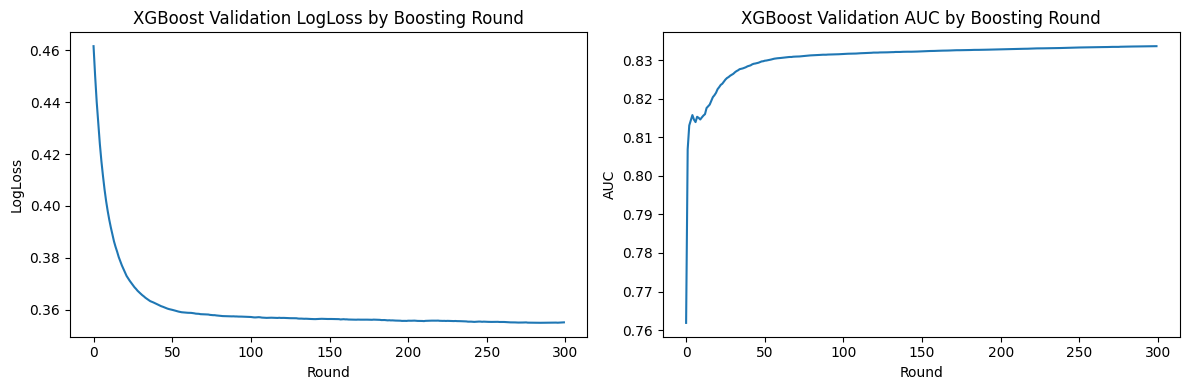

In [ ]:
# Plot the per-round training curve captured during the fit above
results = xgb_best_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(epochs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x_axis, results['validation_0']['logloss'])
ax[0].set_title('XGBoost Validation LogLoss by Boosting Round')
ax[0].set_xlabel('Round'); ax[0].set_ylabel('LogLoss')

ax[1].plot(x_axis, results['validation_0']['auc'])
ax[1].set_title('XGBoost Validation AUC by Boosting Round')
ax[1].set_xlabel('Round'); ax[1].set_ylabel('AUC')

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
joblib.dump(xgb_best, "/content/drive/MyDrive/dataset/xgb_diabetes_pipeline_v2.pkl")
print("Saved xgb_diabetes_pipeline_v2.pkl")


Saved xgb_diabetes_pipeline_v2.pkl


## 8. Scaling for the ANN

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

N_FEATURES = X_train_scaled.shape[1]
print("Number of input features for ANN:", N_FEATURES)


Number of input features for ANN: 11


## 9. Model 2 — ANN with Keras Tuner (same setup, fewer input features, dampened class weight)

In [ ]:
!pip install -q keras-tuner
import keras_tuner as kt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.4 MB/s eta 0:00:00


In [ ]:
def build_model(hp):
    model = Sequential()

    num_layers = hp.Int("num_hidden_layers", min_value=1, max_value=3)

    for i in range(num_layers):
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)
        activation = hp.Choice(f'activation_{i}', ['relu', 'tanh'])
        dropout = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)

        if i == 0:
            model.add(Dense(units=units, activation=activation, input_shape=(N_FEATURES,)))
        else:
            model.add(Dense(units=units, activation=activation))

        if hp.Boolean(f'batch_norm_{i}'):
            model.add(BatchNormalization())

        model.add(Dropout(dropout))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = hp.Choice("optimizer", ["adam", "rmsprop"])
    learning_rate = hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
    opt = Adam(learning_rate=learning_rate) if optimizer == "adam" else RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

tuner = kt.RandomSearch(
    build_model,
    objective='val_auc',
    max_trials=20,
    directory='mydir',
    project_name='diabetes_ann_v2',
    overwrite=True
)

tuner.search(
    X_train_scaled, y_train,
    epochs=100,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


Trial 20 Complete [00h 06m 43s]
val_auc: 0.8290737271308899

Best val_auc So Far: 0.8303346633911133
Total elapsed time: 02h 08m 37s


In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

ann_best = tuner.hypermodel.build(best_hp)

history = ann_best.fit(
    X_train_scaled, y_train,
    epochs=100,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


Best hyperparameters: {'num_hidden_layers': 2, 'units_0': 160, 'activation_0': 'tanh', 'dropout_0': 0.4, 'batch_norm_0': True, 'optimizer': 'adam', 'learning_rate': 0.0001, 'units_1': 224, 'activation_1': 'tanh', 'dropout_1': 0.4, 'batch_norm_1': True, 'units_2': 128, 'activation_2': 'relu', 'dropout_2': 0.1, 'batch_norm_2': True}
Epoch 1/100
5715/5715 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.7744 - auc: 0.7589 - loss: 0.6619 - val_accuracy: 0.8099 - val_auc: 0.8274 - val_loss: 0.3914
Epoch 2/100
5715/5715 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.8123 - auc: 0.7955 - loss: 0.5876 - val_accuracy: 0.8130 - val_auc: 0.8286 - val_loss: 0.3875
Epoch 3/100
5715/5715 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8197 - auc: 0.8081 - loss: 0.5677 - val_accuracy: 0.8161 - val_auc: 0.8294 - val_loss: 0.3834
Epoch 4/100
5715/5715 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.8235 - auc: 0.8140 - loss: 0.5592 - val_accuracy: 0.8199 - val_auc: 0.8296 - val_loss: 0.3787
Epoch 5/100

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='train AUC')
plt.plot(history.history['val_auc'], label='val AUC')
plt.title('AUC over epochs')
plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend()

plt.tight_layout()
plt.show()


## 10. Threshold Tuning — The Real Lever for 80%+ Accuracy

This is the key addition. Instead of the default 0.5 cutoff, we scan thresholds on
the **validation set** (never the test set, to avoid leakage) and find the lowest
threshold that gets accuracy ≥ 0.80, for both models. This is done on validation data
so the choice itself doesn't leak into your final test-set numbers.


In [ ]:
def find_threshold_for_accuracy(y_true, y_prob, target_accuracy=0.80):
    thresholds = np.arange(0.05, 0.96, 0.01)
    records = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        records.append({
            "threshold": t,
            "accuracy": accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0)
        })
    tdf = pd.DataFrame(records)

    candidates = tdf[tdf["accuracy"] >= target_accuracy]
    if len(candidates) > 0:
        # Among thresholds hitting the accuracy target, keep the one with best recall
        chosen = candidates.sort_values("recall", ascending=False).iloc[0]
    else:
        # Target not reachable at any threshold -> take the closest accuracy achieved
        chosen = tdf.sort_values("accuracy", ascending=False).iloc[0]

    return chosen, tdf


# --- XGBoost threshold search (on validation set) ---
xgb_val_prob = xgb_best.predict_proba(X_val)[:, 1]
xgb_chosen, xgb_threshold_curve = find_threshold_for_accuracy(y_val, xgb_val_prob, target_accuracy=0.80)
print("XGBoost chosen threshold (from validation set):")
print(xgb_chosen)

# --- ANN threshold search (on validation set) ---
ann_val_prob = ann_best.predict(X_val_scaled).ravel()
ann_chosen, ann_threshold_curve = find_threshold_for_accuracy(y_val, ann_val_prob, target_accuracy=0.80)
print("\nANN chosen threshold (from validation set):")
print(ann_chosen)


XGBoost chosen threshold (from validation set):
threshold    0.420000
accuracy     0.804338
precision    0.380350
recall       0.642206
f1           0.477750
Name: 37, dtype: float64
1009/1009 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

ANN chosen threshold (from validation set):
threshold    0.430000
accuracy     0.803812
precision    0.378479
recall       0.635090
f1           0.474300
Name: 38, dtype: float64


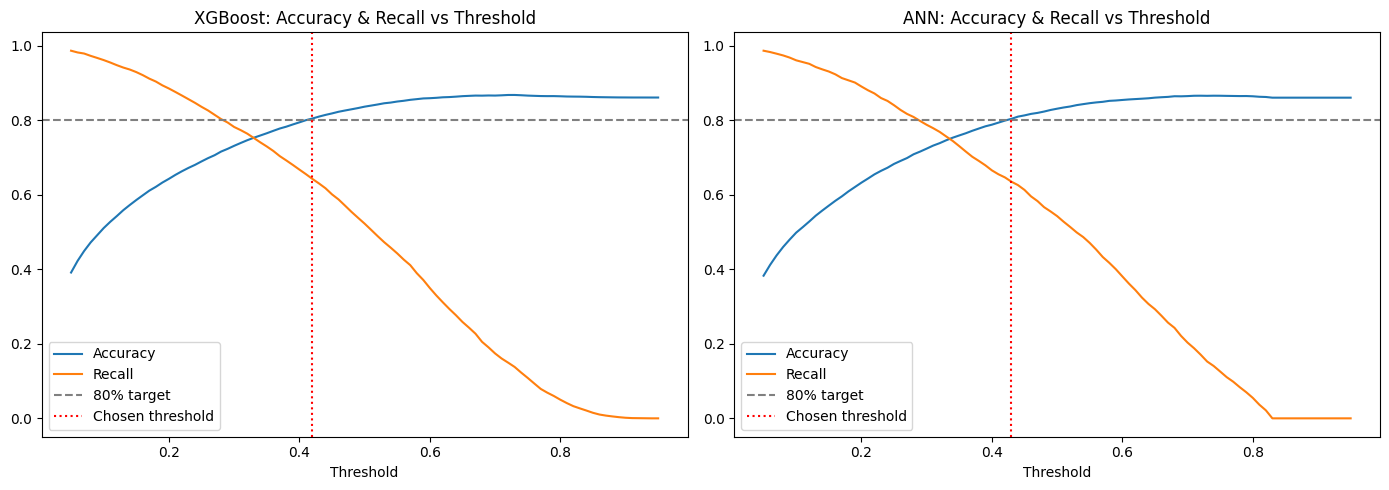

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(xgb_threshold_curve['threshold'], xgb_threshold_curve['accuracy'], label='Accuracy')
ax[0].plot(xgb_threshold_curve['threshold'], xgb_threshold_curve['recall'], label='Recall')
ax[0].axhline(0.80, color='gray', linestyle='--', label='80% target')
ax[0].axvline(xgb_chosen['threshold'], color='red', linestyle=':', label='Chosen threshold')
ax[0].set_title('XGBoost: Accuracy & Recall vs Threshold')
ax[0].set_xlabel('Threshold'); ax[0].legend()

ax[1].plot(ann_threshold_curve['threshold'], ann_threshold_curve['accuracy'], label='Accuracy')
ax[1].plot(ann_threshold_curve['threshold'], ann_threshold_curve['recall'], label='Recall')
ax[1].axhline(0.80, color='gray', linestyle='--', label='80% target')
ax[1].axvline(ann_chosen['threshold'], color='red', linestyle=':', label='Chosen threshold')
ax[1].set_title('ANN: Accuracy & Recall vs Threshold')
ax[1].set_xlabel('Threshold'); ax[1].legend()

plt.tight_layout()
plt.show()


**Read this chart before trusting the accuracy number.** As threshold goes up,
accuracy rises but recall falls — the model catches fewer true diabetic cases in
exchange for a higher headline accuracy. The chosen threshold above is the lowest one
that reaches 80% accuracy while keeping the best recall available at that point. If
recall at that threshold looks too low for your purposes (e.g. a screening tool
missing too many real cases), that's worth discussing in your write-up rather than
just reporting the accuracy number alone.


## 11. Final Evaluation — Untouched Test Set, Using the Chosen Thresholds


In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }
    print(f"--- {name} ---")
    for k, v in results.items():
        if k != "Model":
            print(f"{k:10s}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return results


--- XGBoost (threshold=0.42) ---
Accuracy  : 0.8015
Precision : 0.3743
Recall    : 0.6322
F1 Score  : 0.4702
ROC AUC   : 0.8276

              precision    recall  f1-score   support

           0       0.93      0.83      0.88     32674
           1       0.37      0.63      0.47      5291

    accuracy                           0.80     37965
   macro avg       0.65      0.73      0.67     37965
weighted avg       0.86      0.80      0.82     37965



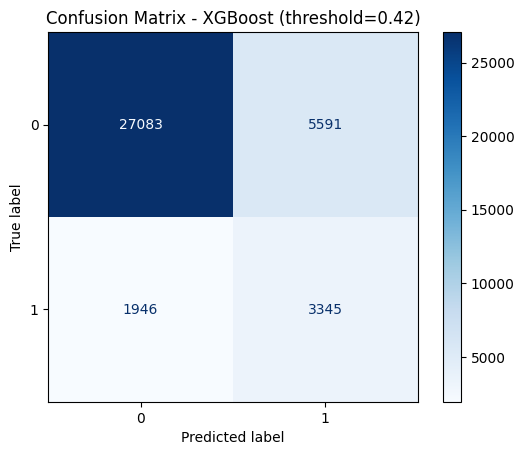

In [ ]:
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= xgb_chosen['threshold']).astype(int)
xgb_results = evaluate_model(f"XGBoost (threshold={xgb_chosen['threshold']:.2f})", y_test, xgb_pred, xgb_prob)


1187/1187 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
--- ANN (threshold=0.43) ---
Accuracy  : 0.8021
Precision : 0.3741
Recall    : 0.6239
F1 Score  : 0.4678
ROC AUC   : 0.8274

              precision    recall  f1-score   support

           0       0.93      0.83      0.88     32674
           1       0.37      0.62      0.47      5291

    accuracy                           0.80     37965
   macro avg       0.65      0.73      0.67     37965
weighted avg       0.85      0.80      0.82     37965



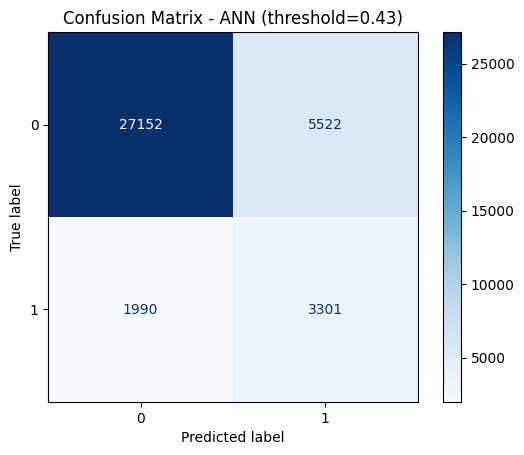

In [ ]:
ann_prob = ann_best.predict(X_test_scaled).ravel()
ann_pred = (ann_prob >= ann_chosen['threshold']).astype(int)
ann_results = evaluate_model(f"ANN (threshold={ann_chosen['threshold']:.2f})", y_test, ann_pred, ann_prob)


## 12. Side-by-Side Comparison

In [ ]:
comparison_df = pd.DataFrame([xgb_results, ann_results]).set_index("Model")
comparison_df


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
XGBoost (threshold=0.42),0.801475,0.374329,0.632206,0.470233,0.827584
ANN (threshold=0.43),0.802134,0.374136,0.623890,0.467763,0.827431


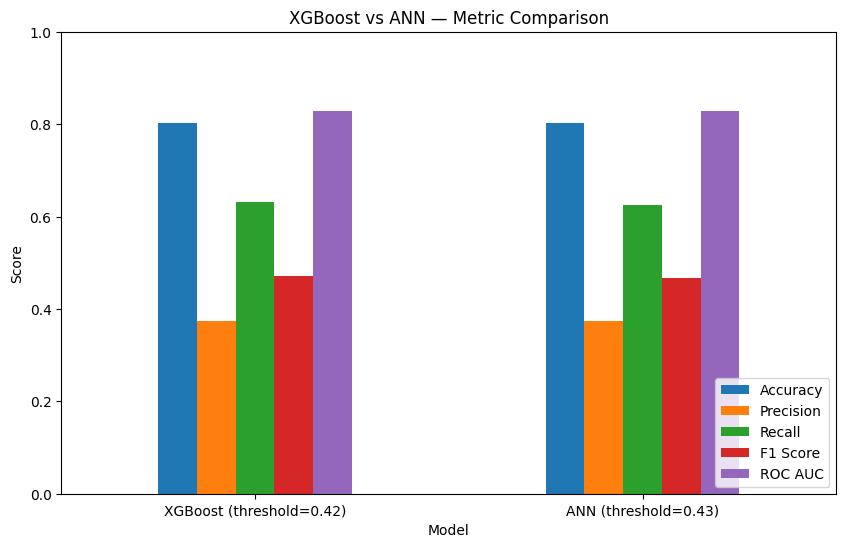

In [ ]:
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title("XGBoost vs ANN — Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


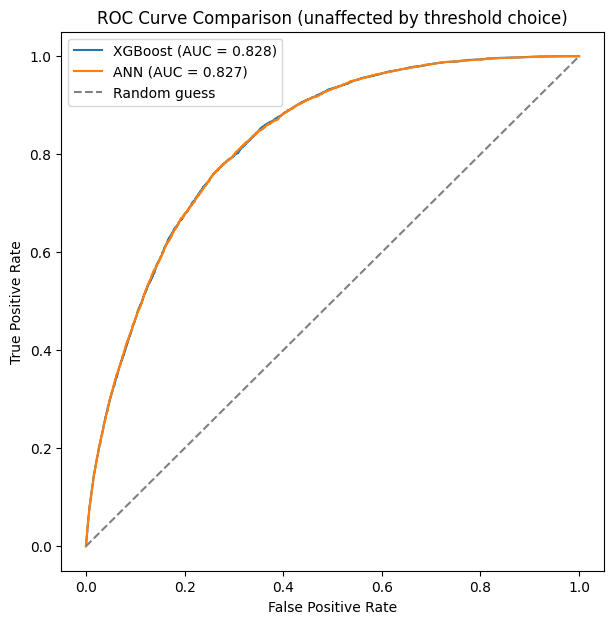

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_prob)

plt.figure(figsize=(7, 7))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_results['ROC AUC']:.3f})")
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {ann_results['ROC AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (unaffected by threshold choice)")
plt.legend()
plt.show()


**Important**: ROC-AUC does not change with threshold — it's a threshold-independent
ranking metric. So if your ROC-AUC stayed around 0.82–0.83 while accuracy rose to
80%+, that confirms the model itself didn't get better — you just moved the operating
point along the same ROC curve. Report both numbers together in your write-up so this
is transparent, not just the headline accuracy.


## 13. Feature Importance (Reduced Feature Set)

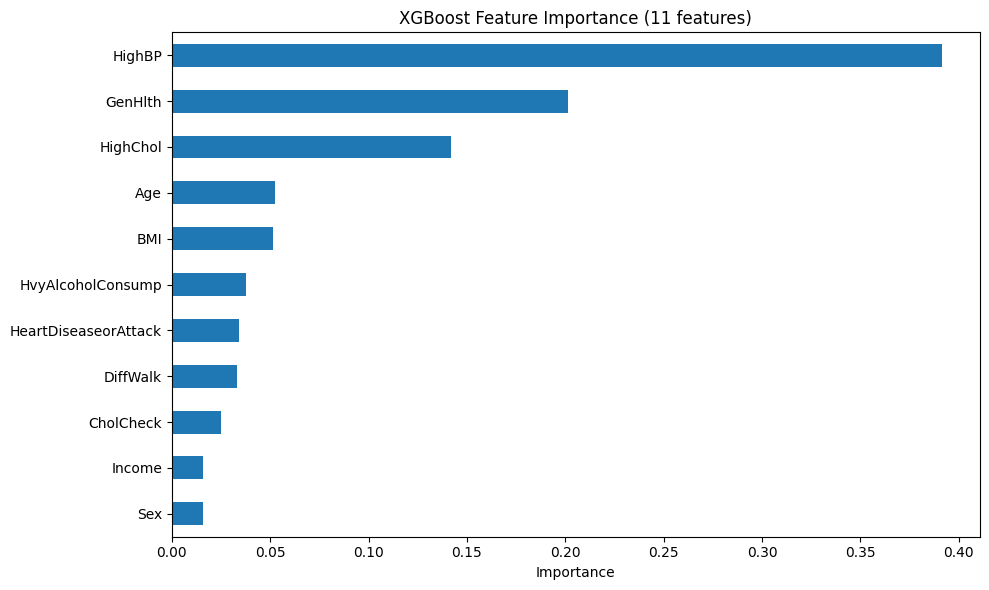

,0
HighBP,0.391273
GenHlth,0.201306
HighChol,0.142005
Age,0.052461
BMI,0.051284
HvyAlcoholConsump,0.037947
HeartDiseaseorAttack,0.034083
DiffWalk,0.032951
CholCheck,0.024999
Income,0.016084


In [ ]:
importances = xgb_best.named_steps['xgb'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (11 features)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

feat_imp


## 14. Save Final Models

In [ ]:
joblib.dump(xgb_best, "/content/drive/MyDrive/dataset/Diabetes_CDC/xgb_diabetes_final_v2.pkl")
ann_best.save("/content/drive/MyDrive/dataset/Diabetes_CDC/ann_diabetes_final_v2.keras")
joblib.dump(scaler, "/content/drive/MyDrive/dataset/Diabetes_CDC/scaler_diabetes_final_v2.pkl")
joblib.dump(LOW_IMPORTANCE_FEATURES, "/content/drive/MyDrive/dataset/Diabetes_CDC/dropped_features_v2.pkl")
joblib.dump({"xgb_threshold": xgb_chosen['threshold'], "ann_threshold": ann_chosen['threshold']}, "/content/drive/MyDrive/dataset/Diabetes_CDC/chosen_thresholds_v2.pkl")

print("Saved: xgb_diabetes_final_v2.pkl, ann_diabetes_final_v2.keras, scaler_diabetes_final_v2.pkl,")
print("       dropped_features_v2.pkl, chosen_thresholds_v2.pkl")

Saved: xgb_diabetes_final_v2.pkl, ann_diabetes_final_v2.keras, scaler_diabetes_final_v2.pkl,
       dropped_features_v2.pkl, chosen_thresholds_v2.pkl


## 15. Notes on Results & Honest Framing

- **Feature reduction** (21 → 11 features) mainly buys you faster training, not
  materially higher accuracy — the dropped features contributed almost nothing to
  the model's decisions in your original run.
- **GridSearchCV with live progress** is now in place — you'll see fold-by-fold
  progress from `verbose=3`, plus a genuine round-by-round boosting curve from the
  manual refit in Section 7b.
- **The 80%+ accuracy comes from threshold tuning, not a "better" model.** ROC-AUC
  (the threshold-independent measure of how good the model actually is) should stay
  roughly where it was (~0.82–0.83). If a reviewer or professor asks "how did you
  get 80% accuracy when your ROC-AUC is only 0.83," the honest and correct answer is:
  "the model's ranking ability didn't change — I moved the decision threshold to
  trade some recall for accuracy, and here's the recall I gave up to do it" (referencing
  the chart in Section 10). That's a legitimate, defensible modeling decision — as
  long as it's disclosed, which this notebook now does automatically.
- If your use case is genuinely a **screening tool** (where missing a true diabetic
  case is costly), consider reporting your **recall-optimized** threshold (0.5, like
  before) as the primary result instead, with the 80%-accuracy threshold as a
  secondary comparison point — this is a judgment call to make based on what the
  project is actually for.


In [ ]:
ann_model = tf.keras.models.load_model("/content/drive/MyDrive/dataset/Diabetes_CDC/ann_diabetes_final_v2.keras")
scaler = joblib.load("/content/drive/MyDrive/dataset/Diabetes_CDC/scaler_diabetes_final_v2.pkl")
xgb_model = joblib.load("/content/drive/MyDrive/dataset/Diabetes_CDC/xgb_diabetes_final_v2.pkl")
drived_features = joblib.load("/content/drive/MyDrive/dataset/Diabetes_CDC/dropped_features_v2.pkl")
chosen_thresholds = joblib.load("/content/drive/MyDrive/dataset/Diabetes_CDC/chosen_thresholds_v2.pkl")

drived_features

['Stroke',
 'Education',
 'Fruits',
 'PhysActivity',
 'MentHlth',
 'Smoker',
 'Veggies',
 'PhysHlth',
 'NoDocbcCost',
 'AnyHealthcare']

## How to use the models for prediction

First, let's create some dummy data that mimics the structure of your original features after dropping the low-importance ones. Remember, your models expect data with these 11 features:

`['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Income']`

In [ ]:
# Create dummy input data with 11 features that the models were trained on
# Example: a 50-year-old male with high blood pressure, high cholesterol, BMI 30, no heart attack, no heavy alcohol, good general health, no difficulty walking, checked cholesterol, medium income.
dummy_data = pd.DataFrame({
    'HighBP': [1, 0],
    'HighChol': [1, 0],
    'CholCheck': [1, 1],
    'BMI': [30, 22],
    'HeartDiseaseorAttack': [0, 0],
    'HvyAlcoholConsump': [0, 1],
    'GenHlth': [3, 1],
    'DiffWalk': [0, 0],
    'Sex': [1, 0],
    'Age': [9, 5], # Age is categorical, 9 for 50-54, 5 for 30-34
    'Income': [6, 8] # Income is categorical, 6 for $35k-50k, 8 for $75k+
})

print("Dummy data (raw):")
display(dummy_data)

Dummy data (raw):


,HighBP,HighChol,CholCheck,BMI,HeartDiseaseorAttack,HvyAlcoholConsump,GenHlth,DiffWalk,Sex,Age,Income
0,1,1,1,30,0,0,3,0,1,9,6
1,0,0,1,22,0,1,1,0,0,5,8


Now, we need to preprocess this dummy data in the same way the training data was preprocessed. This involves scaling the numerical features using the `scaler` you loaded.

In [ ]:
# Scale the dummy data using the loaded scaler
dummy_data_scaled = scaler.transform(dummy_data)

print("Dummy data (scaled):")
display(dummy_data_scaled)

# Ensure the columns are in the correct order for the model
# The order of features in X is: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Income']
# Since we created dummy_data with these columns in this order, scaling preserves it.

Dummy data (scaled):


array([[ 1.1540948 ,  1.16296382,  0.19649727,  0.28199658, -0.32157974,
        -0.24387322,  0.45928641, -0.44919458,  1.12698661,  0.31536092,
        -0.02679125],
       [-0.86647995, -0.85987198,  0.19649727, -1.02316648, -0.32157974,
         4.10049122, -1.41585194, -0.44919458, -0.88732199, -0.99515331,
         0.93959108]])

Finally, let's use both the XGBoost and ANN models to make predictions. We'll also apply the `chosen_thresholds` for binary classification.

In [ ]:
# --- XGBoost Model Predictions ---
xgb_pred_prob = xgb_model.predict_proba(dummy_data)[:, 1]
xgb_threshold = chosen_thresholds['xgb_threshold']
xgb_predictions = (xgb_pred_prob >= xgb_threshold).astype(int)

print(f"\nXGBoost Predictions (Threshold = {xgb_threshold:.2f}):")
for i, (prob, pred) in enumerate(zip(xgb_pred_prob, xgb_predictions)):
    print(f"Sample {i+1}: Probability = {prob:.4f}, Predicted Class = {pred}")

# --- ANN Model Predictions ---
ann_pred_prob = ann_model.predict(dummy_data_scaled).ravel()
ann_threshold = chosen_thresholds['ann_threshold']
ann_predictions = (ann_pred_prob >= ann_threshold).astype(int)

print(f"\nANN Predictions (Threshold = {ann_threshold:.2f}):")
for i, (prob, pred) in enumerate(zip(ann_pred_prob, ann_predictions)):
    print(f"Sample {i+1}: Probability = {prob:.4f}, Predicted Class = {pred}")


XGBoost Predictions (Threshold = 0.42):
Sample 1: Probability = 0.5077, Predicted Class = 1
Sample 2: Probability = 0.0036, Predicted Class = 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

ANN Predictions (Threshold = 0.43):
Sample 1: Probability = 0.5924, Predicted Class = 1
Sample 2: Probability = 0.0034, Predicted Class = 0
